<h1 style="color: #C0392B;">
Les régions françaises les plus dynamiques : peut-on prédire la création d’entreprise ?</h1>



<span style="color: #2E86C1;"> *Par Tom Proust, Tristan Czarnecki et Thomas Favant*
</span>.

Comment a-t-on défini les créations d'entreprises? (Startup? PME? ???)

### Installation des bibliothèques

In [25]:
#mettre tous les imports nécessaires pour l'exécution de toutes les fonctions du dossiers 'mes_fonctions.py'
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm



### Plan

1.	Récupération de données
2.	Statistiques descriptives
3.	Modélisation

<h1 style="color: #C0392B;">
2. Statistiques descriptives </h1>

Le but est d'analyser la corrélation entre le taux de chômage et la création d'entreprises par 1000 habitants dans différentes régions et périodes.Pour cela, on écrit une fonction dans 'analyse_correlation_chomage_creation.py' qui calcule le coefficient de corrélation de Pearson entre le taux de chômage et la création d'entreprises par 1000 habitants.

<>:2: SyntaxWarning: invalid escape sequence '\V'
<>:2: SyntaxWarning: invalid escape sequence '\V'
C:\Users\thoma\AppData\Local\Temp\ipykernel_18052\352451589.py:2: SyntaxWarning: invalid escape sequence '\V'
  correlation_chomage_creation=pd.read_csv("data\Variables explicatives\correlation_chomage_creation.csv")


--- Analyse Statistique ---
Coefficient de corrélation (Pearson) : -0.35
Tendance : Inverse (Plus le chômage est haut, moins on crée).


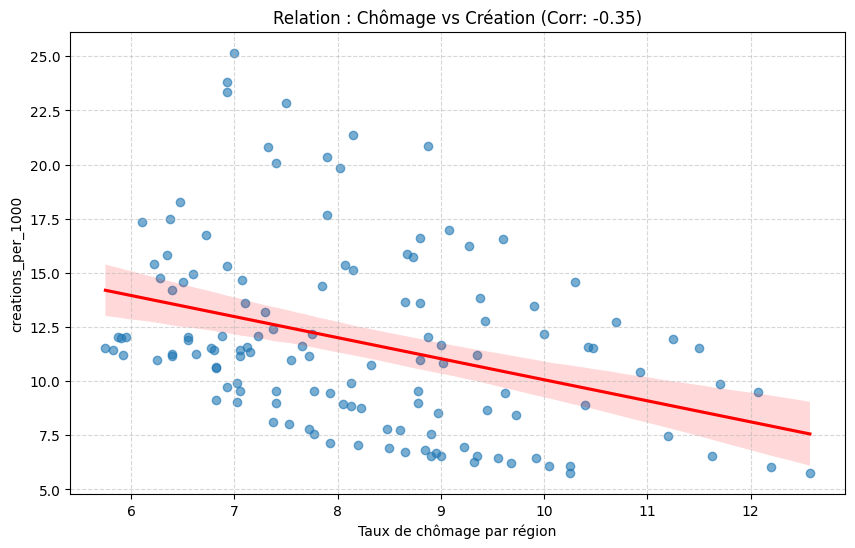

In [26]:
import pandas as pd
correlation_chomage_creation=pd.read_csv("data\Variables explicatives\correlation_chomage_creation.csv")

# Là, tu importes ta fonction depuis ton fichier
from mes_fonctions import analyser_relation_chomage_creation

# Et tu l'utilises
analyser_relation_chomage_creation(correlation_chomage_creation)



1. L'Interprétation Statistique
Signe Négatif (-) : Il y a une relation inverse. Quand le chômage augmente, le taux de création d'entreprise a tendance à diminuer.Force (0.35) : C'est une corrélation modérée. Ce n'est pas un lien mécanique absolu (les points ne sont pas tous collés à la ligne), mais la tendance est visible et significative.

2. L'Interprétation Économique : 
"Pull" vs "Push". C'est le point crucial pour ton étude. Hypothèse "Push" (Nécessité) rejetée : Si le chômage poussait les gens à créer leur entreprise par dépit, la pente serait montante (positive). Or, ici, elle descend.Hypothèse "Pull" (Opportunité) validée : Tes données suggèrent que la bonne santé économique favorise la création.Quand le chômage est faible (signe d'une économie dynamique), les gens ont confiance, accès au crédit, et voient des opportunités de marché $\rightarrow$ Ils créent des entreprises.Quand le chômage est élevé (économie en berne), le climat est trop incertain $\rightarrow$ La création freine.3. Analyse Visuelle (Ce que le graphique raconte)

En regardant les points, on voit deux phénomènes distincts :Le "Plafond de Verre" du chômage élevé : Regarde la partie droite du graphique (chômage > 10%). Il n'y a aucun point avec un taux de création très élevé. Un fort chômage semble "interdire" les explosions de création d'entreprises.La grande disparité en zone de faible chômage : Regarde la partie gauche (chômage entre 6% et 8%).Tu as des points très hauts (création > 20%).Mais tu as aussi des points bas (création ~ 7-8%).Conclusion : Un faible chômage est une condition nécessaire mais pas suffisante pour avoir un fort taux de création. D'autres facteurs entrent en jeu ici (tourisme ? dynamisme spécifique à une métropole ?).Conclusion pour ton projetTu peux affirmer que dans les régions étudiées, la création d'entreprise est pro-cyclique (elle va bien quand l'économie va bien). L'effet "refuge" (créer sa boite parce qu'on ne trouve pas de travail) n'est pas la force dominante à l'échelle macro-régionale.

<h1 style="color: #C0392B;">
3. Modélisation </h1>

<h1 style="color: #C0392B;">
3.1. Régression linéaire 1 </h1>

Afin d'identifier les facteurs influençant le dynamisme entrepreneurial des régions, nous procédons à une régression linéaire multiple (Méthode des Moindres Carrés Ordinaires - OLS).Le modèle économétrique testé est le suivant :$$TauxCréation_i = \beta_0 + \beta_1 \cdot Diplôme + \beta_2 \cdot Chômage + \beta_3 \cdot VariationPop + \beta_4 \cdot Densité + \epsilon_i$$

Choix des variables :Variable expliquée ($Y$) : Le taux de création d'entreprises (pour 1000 habitants), indicateur direct du dynamisme entrepreneurial.

Variables explicatives ($X$) :
- Capital Humain : Le pourcentage de diplômés du supérieur (proxy du niveau de qualification de la région).
- Conjoncture Économique : Le taux de chômage (pour tester l'effet "push" vs "pull").
- Dynamisme Démographique : La variation de la population (attractivité du territoire)
- Agglomération : La densité de population (effets de métropolisation).

Hypothèse de modélisation : Nous utilisons une approche "Pooled OLS" sur l'ensemble de notre panel (130 observations : 13 régions $\times$ 10 années). Cette méthode permet d'inclure des variables structurelles invariantes sur la période étudiée (comme le niveau de diplôme, fixé ici à son niveau de 2022) et de mesurer leur impact global sur les disparités inter-régionales.

Pour créer le dataset contenant la variable explicative et les variables explicatives, nous l'avons fait dans le notebook "regression.ipynb" pour vérifier que les merges des datasets de nos variables explicatives s'effectuaient correctement'. Le dataset s'appelle 'regression1'.

Les données sur les diplômes des français n'étaient disponibles qu'en 2022 sur l'INSEE donc nous avons fait une **hypothèse de stabilité** :
Le niveau d'éducation d'une région change très lentement. On peut raisonnablement supposer que si une région est très diplômée en 2022, elle l'était aussi (relativement aux autres) en 2015.

In [27]:
regression1 = pd.read_csv("data/Variables explicatives/regression1.csv")

# 1. Définition des variables
y = regression1['creations_per_1000']

# X = Les variables explicatives
features = [
    'Taux de chômage par région', 
    'Pourcentage_diplomes_superieur',     
    'variation_population_pourcentage', 
    'densité de population'
]
X = regression1[features]

# 2. Ajout de la constante (Intercept)
X = sm.add_constant(X)

# 3. Création et ajustement du modèle (MCO = Moindres Carrés Ordinaires)
model = sm.OLS(y, X)
results = model.fit()

# 4. Affichage du rapport complet
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     42.58
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           1.70e-22
Time:                        22:34:47   Log-Likelihood:                -316.14
No. Observations:                 130   AIC:                             642.3
Df Residuals:                     125   BIC:                             656.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### 1. Performance globale du modèle.

**Qualité de l'ajustement ($R^2$)** : 
Le $R^2$ est de 0.577. Cela signifie que notre modèle explique 57,7 % de la variance du taux de création d'entreprises. 
Pour des données socio-économiques, c'est un score élevé, indiquant que les variables choisies sont très pertinentes pour expliquer le phénomène.Significativité globale (F-statistic) : La probabilité associée (Prob F-statistic: $1.70e-22$) est quasi nulle, ce qui confirme que le modèle dans son ensemble est statistiquement valide.

### 2. Analyse des déterminants (Variables significatives).
Trois variables ont un impact statistiquement significatif (P-value < 0.05) sur la création d'entreprise :
- **Le Taux de Chômage** (Coef: -0.82, P<0.001) :Impact : Il existe une relation négative forte. Toutes choses égales par ailleurs, une augmentation de 1 point du taux de chômage entraîne une baisse de 0.82 point du taux de création.Interprétation : Ce résultat valide l'effet "Pull" (opportunité). La création d'entreprise est favorisée par une bonne santé économique. L'hypothèse de l'entrepreneuriat de nécessité (effet "Push"), où le chômage pousserait à la création, est ici rejetée.
- **Le Capital Humain / Diplômes** (Coef: +0.53, P<0.001) :Impact : Relation positive. Une augmentation de 1 point du pourcentage de diplômés du supérieur augmente le taux de création de 0.53 point.Interprétation : Le niveau de qualification d'un territoire est un moteur essentiel de l'entrepreneuriat.
- **Le Dynamisme Démographique** (Coef: +2.72, P=0.003) :Impact : Relation positive très forte. Une région dont la population croît attire les créateurs. C'est un indicateur d'attractivité du territoire (demande locale croissante).

### 3. La variable non-significative.
La Densité de population (P=0.540) :Avec une P-value de 0.54 (bien supérieure au seuil de 0.05), nous ne pouvons pas conclure que la densité de population a un impact direct sur la création d'entreprises, une fois que l'on contrôle déjà pour le niveau d'éducation et le chômage. L'effet "métropole" passe probablement déjà par la variable des diplômés.

Note Méthodologique (Limites)Le test de Durbin-Watson est de 0.410, ce qui est faible (loin de la valeur cible de 2). Cela indique une présence d'autocorrélation positive dans les résidus. C'est attendu dans ce type de modèle "Pooled OLS" où les mêmes régions sont suivies sur plusieurs années. Bien que cela n'invalide pas les coefficients (la tendance reste vraie), cela suggère que la précision des intervalles de confiance pourrait être surestimée.